# fuzzy_priority_test.ipynb

In [ ]:
import sys
import os

path_src = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if path_src not in sys.path:
    sys.path.append(path_src)

# Import library
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from fuzzy_system import deadline, kesulitan, urgensi, prioritas, hitung_prioritas

# --- Bagian 1: Memuat dan menampilkan data ---

In [ ]:
# Memuat dataset
data = pd.read_csv('../data/sample_tasks.csv')

print("Data tugas:")
display(data)

Data tugas:


,task,deadline_date,difficulty,urgency
0,Membuat laporan mingguan,2025-05-03,2,7
1,Review kode program,2025-05-12,5,4
2,Riset teknologi baru,2025-05-20,3,3
3,Perbaikan bug kritis,2025-05-01,8,9
4,Persiapan presentasi,2025-05-08,4,6
5,Dokumentasi proyek,2025-05-15,1,2
6,Update sistem keamanan,2025-05-05,7,8
7,Pelatihan tim baru,2025-05-18,3,5
8,Evaluasi performa,2025-05-10,6,7
9,Pengujian fitur baru,2025-05-07,4,6


# --- Bagian 2: Menghitung selisih hari deadline dan prioritas fuzzy ---

In [ ]:
today = datetime.now().date()

# Fungsi untuk menghitung prioritas setiap tugas
def proses_prioritas(df):
    hasil = []
    for index, row in df.iterrows():
        deadline_date = datetime.strptime(row['deadline_date'], '%Y-%m-%d').date()
        days_left = (deadline_date - today).days
        if days_left < 0:
            days_left = 0

        difficulty_scaled = min(row['difficulty'] * 2, 10)
        urgency_scaled = row['urgency']

        prioritas = hitung_prioritas(days_left, difficulty_scaled, urgency_scaled)

        hasil.append({
            'task': row['task'],
            'prioritas': prioritas,
            'days_left': days_left
        })
    return pd.DataFrame(hasil)

df_hasil = proses_prioritas(data)


# --- Bagian 3: Mengurutkan dan menampilkan hasil prioritas ---

In [67]:
df_urut = df_hasil.sort_values(by='prioritas', ascending=False).reset_index(drop=True)

print("Daftar tugas berdasarkan prioritas (tertinggi ke terendah):")
display(df_urut)

Daftar tugas berdasarkan prioritas (tertinggi ke terendah):


,task,prioritas,days_left
0,Perbaikan bug kritis,8.277778,0
1,Evaluasi performa,7.958333,9
2,Membuat laporan mingguan,7.888889,2
3,Update sistem keamanan,7.797619,4
4,Pelatihan tim baru,7.797619,17
5,Persiapan presentasi,7.740741,7
6,Pengujian fitur baru,7.740741,6
7,Review kode program,4.630126,11
8,Riset teknologi baru,3.198810,19
9,Dokumentasi proyek,2.259259,14


# --- Bagian 4: Visualisasi prioritas tugas ---

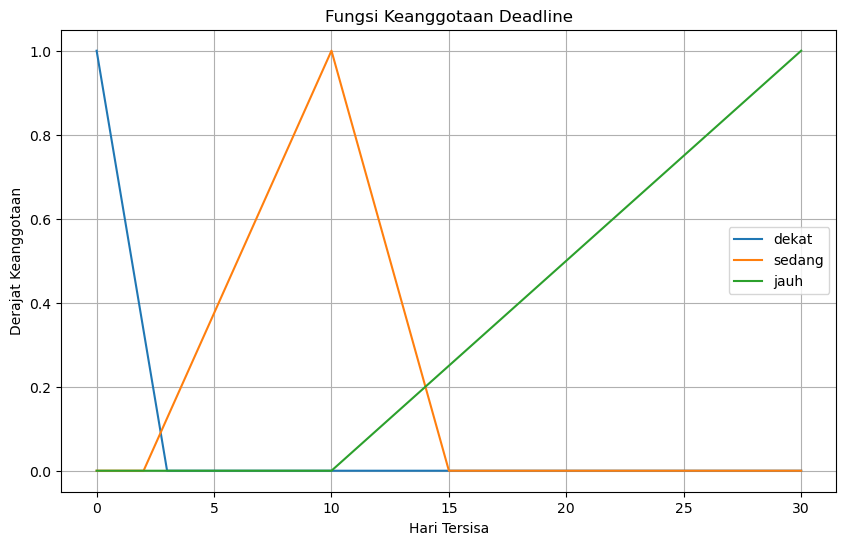

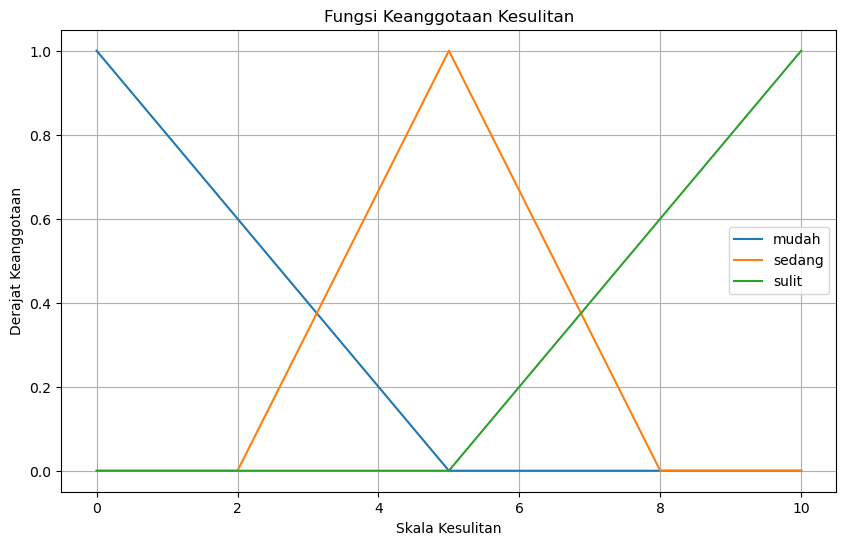

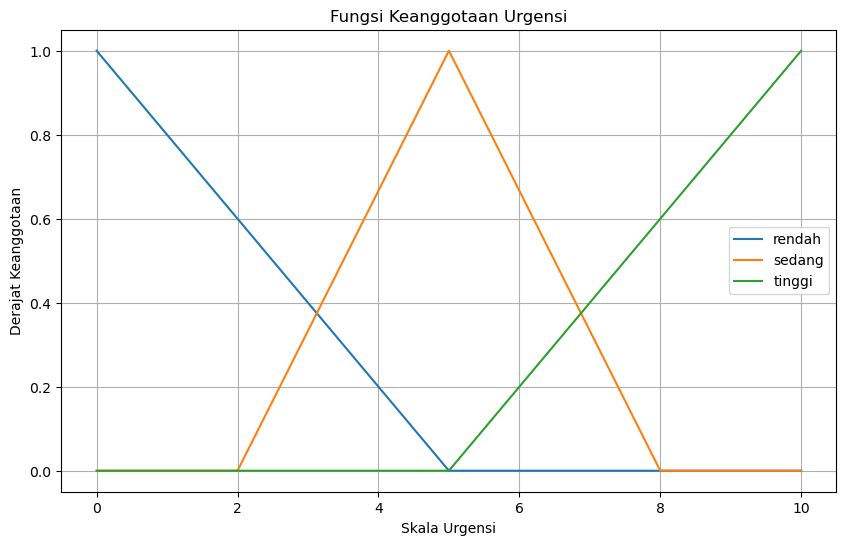

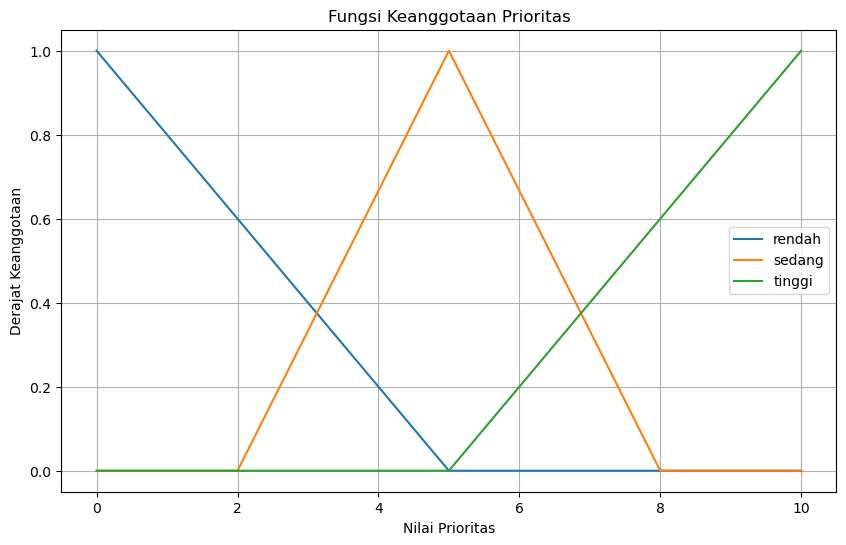

In [70]:
def plot_membership_functions():
    # Plot fungsi keanggotaan untuk deadline
    plt.figure(figsize=(10, 6))
    plt.title('Fungsi Keanggotaan Deadline')
    for label in deadline.terms:
        plt.plot(deadline.universe, deadline[label].mf, label=label)
    plt.xlabel('Hari Tersisa')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot fungsi keanggotaan untuk kesulitan
    plt.figure(figsize=(10, 6))
    plt.title('Fungsi Keanggotaan Kesulitan')
    for label in kesulitan.terms:
        plt.plot(kesulitan.universe, kesulitan[label].mf, label=label)
    plt.xlabel('Skala Kesulitan')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot fungsi keanggotaan untuk urgensi
    plt.figure(figsize=(10, 6))
    plt.title('Fungsi Keanggotaan Urgensi')
    for label in urgensi.terms:
        plt.plot(urgensi.universe, urgensi[label].mf, label=label)
    plt.xlabel('Skala Urgensi')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot fungsi keanggotaan untuk prioritas
    plt.figure(figsize=(10, 6))
    plt.title('Fungsi Keanggotaan Prioritas')
    for label in prioritas.terms:
        plt.plot(prioritas.universe, prioritas[label].mf, label=label)
    plt.xlabel('Nilai Prioritas')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()

# Panggil fungsi untuk menampilkan grafik
plot_membership_functions()

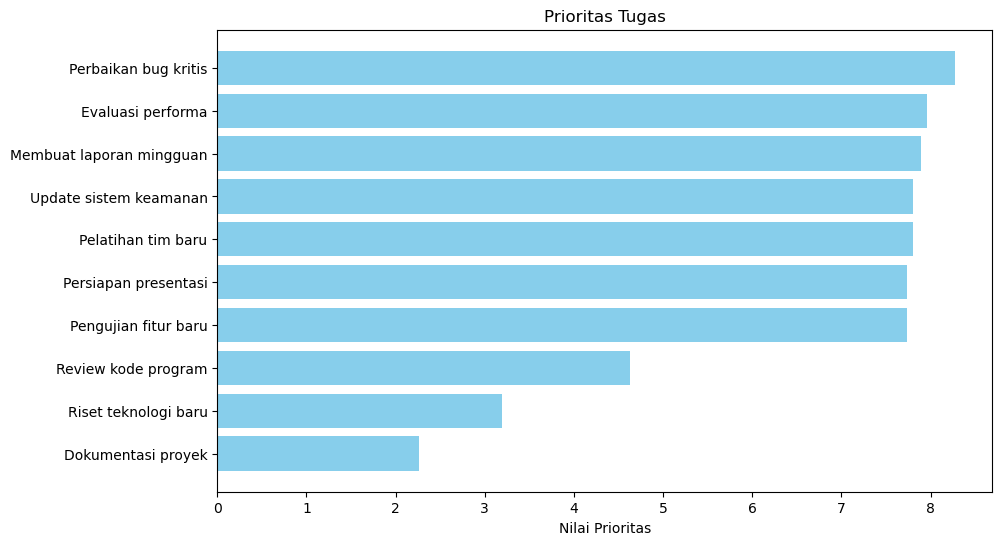

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(df_urut['task'], df_urut['prioritas'], color='skyblue')
plt.xlabel('Nilai Prioritas')
plt.title('Prioritas Tugas')
plt.gca().invert_yaxis()
plt.show()